# Ejercicio 1a: puntos singulares, linealización y retrato de fases

*(Traducción a Python de `ejercicio1a.m` + `ej1a.m`, usando `sympy`, `numpy`, `scipy` y `matplotlib`)*

Encontrar los puntos singulares para el siguiente sistema. Linealizar las ecuaciones en su entorno y determinar la naturaleza de dichos puntos singulares.

$$\dot x_1 = x_2, \qquad \dot x_2 = -x_1+x_2(1-x_2^2)$$

**Nota sobre organización del código:** en MATLAB, `ej1a.m` es un archivo de función aparte, usado dentro de `ejercicio1a.m` a través de un manejador (`@ej1a`). En Python, para mantenerlo todo en un mismo notebook (como pediste), la definimos como una función normal en una celda de código, **antes** de usarla más abajo — recuerda que, a diferencia de MATLAB, en Python una función debe estar definida antes de ser llamada.

In [1]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

sp.init_printing()
np.set_printoptions(precision=4, suppress=True)

## Función de estado (equivalente a `ej1a.m`)

In [2]:
def ej1a(t, x):
    """Ecuaciones de estado del sistema del ejercicio 1a."""
    x1, x2 = x
    return [x2, -x1 + x2*(1 - x2**2)]

## Puntos singulares y linealización

In [3]:
x1, x2, s = sp.symbols('x1 x2 s', real=True)

f = sp.Matrix([
    x2,
    -x1 + x2*(1 - x2**2)
])
f

⎡        x₂        ⎤
⎢                  ⎥
⎢         ⎛      2⎞⎥
⎣-x₁ + x₂⋅⎝1 - x₂ ⎠⎦

In [4]:
J = f.jacobian([x1, x2])
J

⎡0       1    ⎤
⎢             ⎥
⎢            2⎥
⎣-1  1 - 3⋅x₂ ⎦

In [5]:
soluciones = sp.solve(f, [x1, x2], dict=True)
soluciones

Para cada punto de equilibrio: Jacobiano evaluado, autovalores y polinomio característico.

In [6]:
for punto in soluciones:
    print('Punto de equilibrio:', punto)

    Je_sym = J.subs(punto)
    print('Je =')
    display(Je_sym)

    Je_num = np.array(Je_sym.evalf(), dtype=complex)
    E = np.linalg.eigvals(Je_num)
    print('autovalores:', E)

    D = (s*sp.eye(2) - Je_sym).det()
    print('polinomio caracteristico:', sp.expand(D))
    print()

Punto de equilibrio: {x1: 0, x2: 0}
Je =


⎡0   1⎤
⎢     ⎥
⎣-1  1⎦

autovalores: [0.5+0.866j 0.5-0.866j]
polinomio caracteristico: s**2 - s + 1



El único punto de equilibrio es $(0,0)$, con autovalores complejos de parte real positiva (foco inestable).

## Retrato de fases

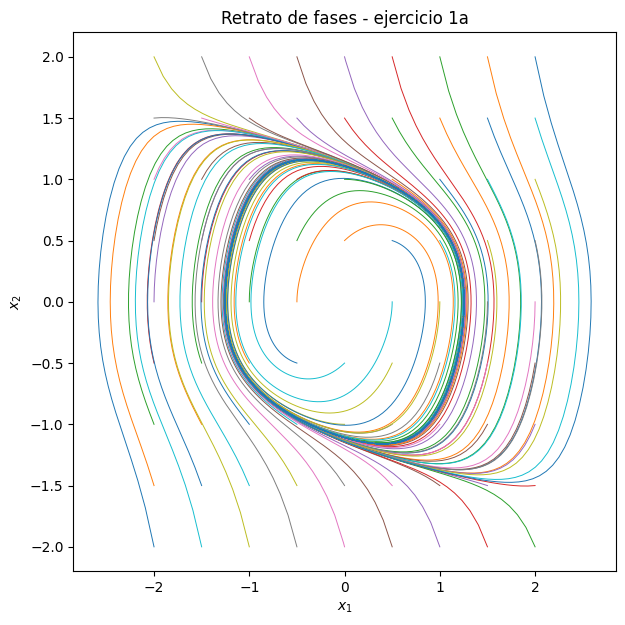

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))

for i in np.arange(-2, 2.001, 0.5):
    for j in np.arange(-2, 2.001, 0.5):
        sol = solve_ivp(ej1a, [0, 50], [i, j], max_step=0.05)
        ax.plot(sol.y[0], sol.y[1], linewidth=0.7)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Retrato de fases - ejercicio 1a')
plt.show()